In [6]:
# Geração de Dados Sintéticos - Hidrólise Enzimática (Versão Compacta)
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Carregamento dos dados com caminho corrigido
csv_path = r'c:\Users\audec\OneDrive\Ethanol-AI\BEPE FAPESP\Enzymatic Hydrolysis\Data Generation\Experimental Data.csv'
if not os.path.exists(csv_path):
    # Tentar caminho alternativo
    csv_path = '../../Enzymatic Hydrolysis/Data Generation/Experimental Data.csv'

data = pd.read_csv(csv_path)
data.columns = data.columns.str.strip()
data = data.rename(columns={
    'Solids Loading [g/L]': 'Solids_Loading',
    'Enzyme Loading [g/L]': 'Enzyme_Loading',
    'Time [h]': 'Time',
    'Glucose Concentration [g/L]': 'Glucose',
    'Xylose Concentration [g/L]': 'Xylose',
    'Cellobiose Concentration [g/L]': 'Cellobiose'
})

print(f"Dados carregados: {data.shape}")

# Definindo variáveis
input_features = ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids_Loading', 'Enzyme_Loading', 'Time']
output_targets = ['Glucose', 'Xylose', 'Cellobiose']
X, y = data[input_features], data[output_targets]

# Divisão e padronização
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Modelos candidatos (apenas os top performers)
models = {
    'Random Forest': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, random_state=42))
}

# Seleção do melhor modelo
best_score, best_model_name, best_model = 0, None, None
print("Treinando modelos...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train_scaled)
    y_pred = model.predict(X_test_scaled)
    score = r2_score(y_test_scaled, y_pred, multioutput='uniform_average')
    print(f"{name}: R² = {score:.4f}")
    if score > best_score:
        best_score, best_model_name, best_model = score, name, model

print(f"\nMelhor modelo: {best_model_name} (R² = {best_score:.4f})")

# Função de geração de dados sintéticos
def generate_synthetic_data(n_samples=1000, add_noise=True, noise_level=0.05):
    np.random.seed(42)
    ranges = {
        'Cellulose': (0.60, 0.70), 'Hemicellulose': (0.07, 0.09), 'Lignin': (0.20, 0.30),
        'Solids_Loading': (100, 250), 'Enzyme_Loading': (0.05, 1.2), 'Time': (0, 100)
    }
    
    # Geração de inputs
    synthetic_inputs = {}
    for feature, (min_val, max_val) in ranges.items():
        if feature == 'Time':
            synthetic_inputs[feature] = np.clip(np.random.exponential(20, n_samples), min_val, max_val)
        else:
            synthetic_inputs[feature] = np.random.uniform(min_val, max_val, n_samples)
    
    synthetic_X = pd.DataFrame(synthetic_inputs)
    synthetic_X_scaled = scaler_X.transform(synthetic_X)
    synthetic_y_scaled = best_model.predict(synthetic_X_scaled)
    synthetic_y = scaler_y.inverse_transform(synthetic_y_scaled)
    synthetic_y_df = pd.DataFrame(synthetic_y, columns=output_targets)
    
    # Adição de ruído
    if add_noise:
        for target in output_targets:
            noise = np.random.normal(0, noise_level * synthetic_y_df[target].std(), n_samples)
            synthetic_y_df[target] = np.maximum(synthetic_y_df[target] + noise, 0)
    
    return pd.concat([synthetic_X, synthetic_y_df], axis=1)

# Geração dos dados sintéticos
print("\nGerando dados sintéticos...")
synthetic_data = generate_synthetic_data(n_samples=1000)
print(f"Dados sintéticos gerados: {synthetic_data.shape}")
print("\nPrimeiras 5 amostras:")
print(synthetic_data.head())

# Salvar dados
try:
    synthetic_data.to_csv('synthetic_hydrolysis_data.csv', index=False)
    print("\nDados salvos em: synthetic_hydrolysis_data.csv")
except Exception as e:
    print(f"Erro ao salvar: {e}")
    
print("\nEstatísticas dos dados sintéticos:")
print(synthetic_data[output_targets].describe())

Dados carregados: (70, 9)
Treinando modelos...
Random Forest: R² = 0.7981
Gradient Boosting: R² = 0.6829

Melhor modelo: Random Forest (R² = 0.7981)

Gerando dados sintéticos...
Dados sintéticos gerados: (1000, 9)

Primeiras 5 amostras:
   Cellulose  Hemicellulose    Lignin  Solids_Loading  Enzyme_Loading  \
0   0.637454       0.073703  0.226171      200.905449        0.707795   
1   0.695071       0.080838  0.224698      219.502210        0.976247   
2   0.673199       0.087459  0.290625      137.570185        0.924185   
3   0.659866       0.084644  0.224955      193.731115        0.226985   
4   0.615602       0.086131  0.227195      185.761897        0.221637   

        Time    Glucose     Xylose  Cellobiose  
0  10.005480  45.426529   9.813279    1.173473  
1  12.827635  48.933769   9.685141    1.270954  
2  38.558099  67.152813  11.408582    1.804150  
3   8.310442  22.987732   5.295763    0.385045  
4  40.750594  58.199280   9.293287    1.418422  

Dados salvos em: synthetic_hy

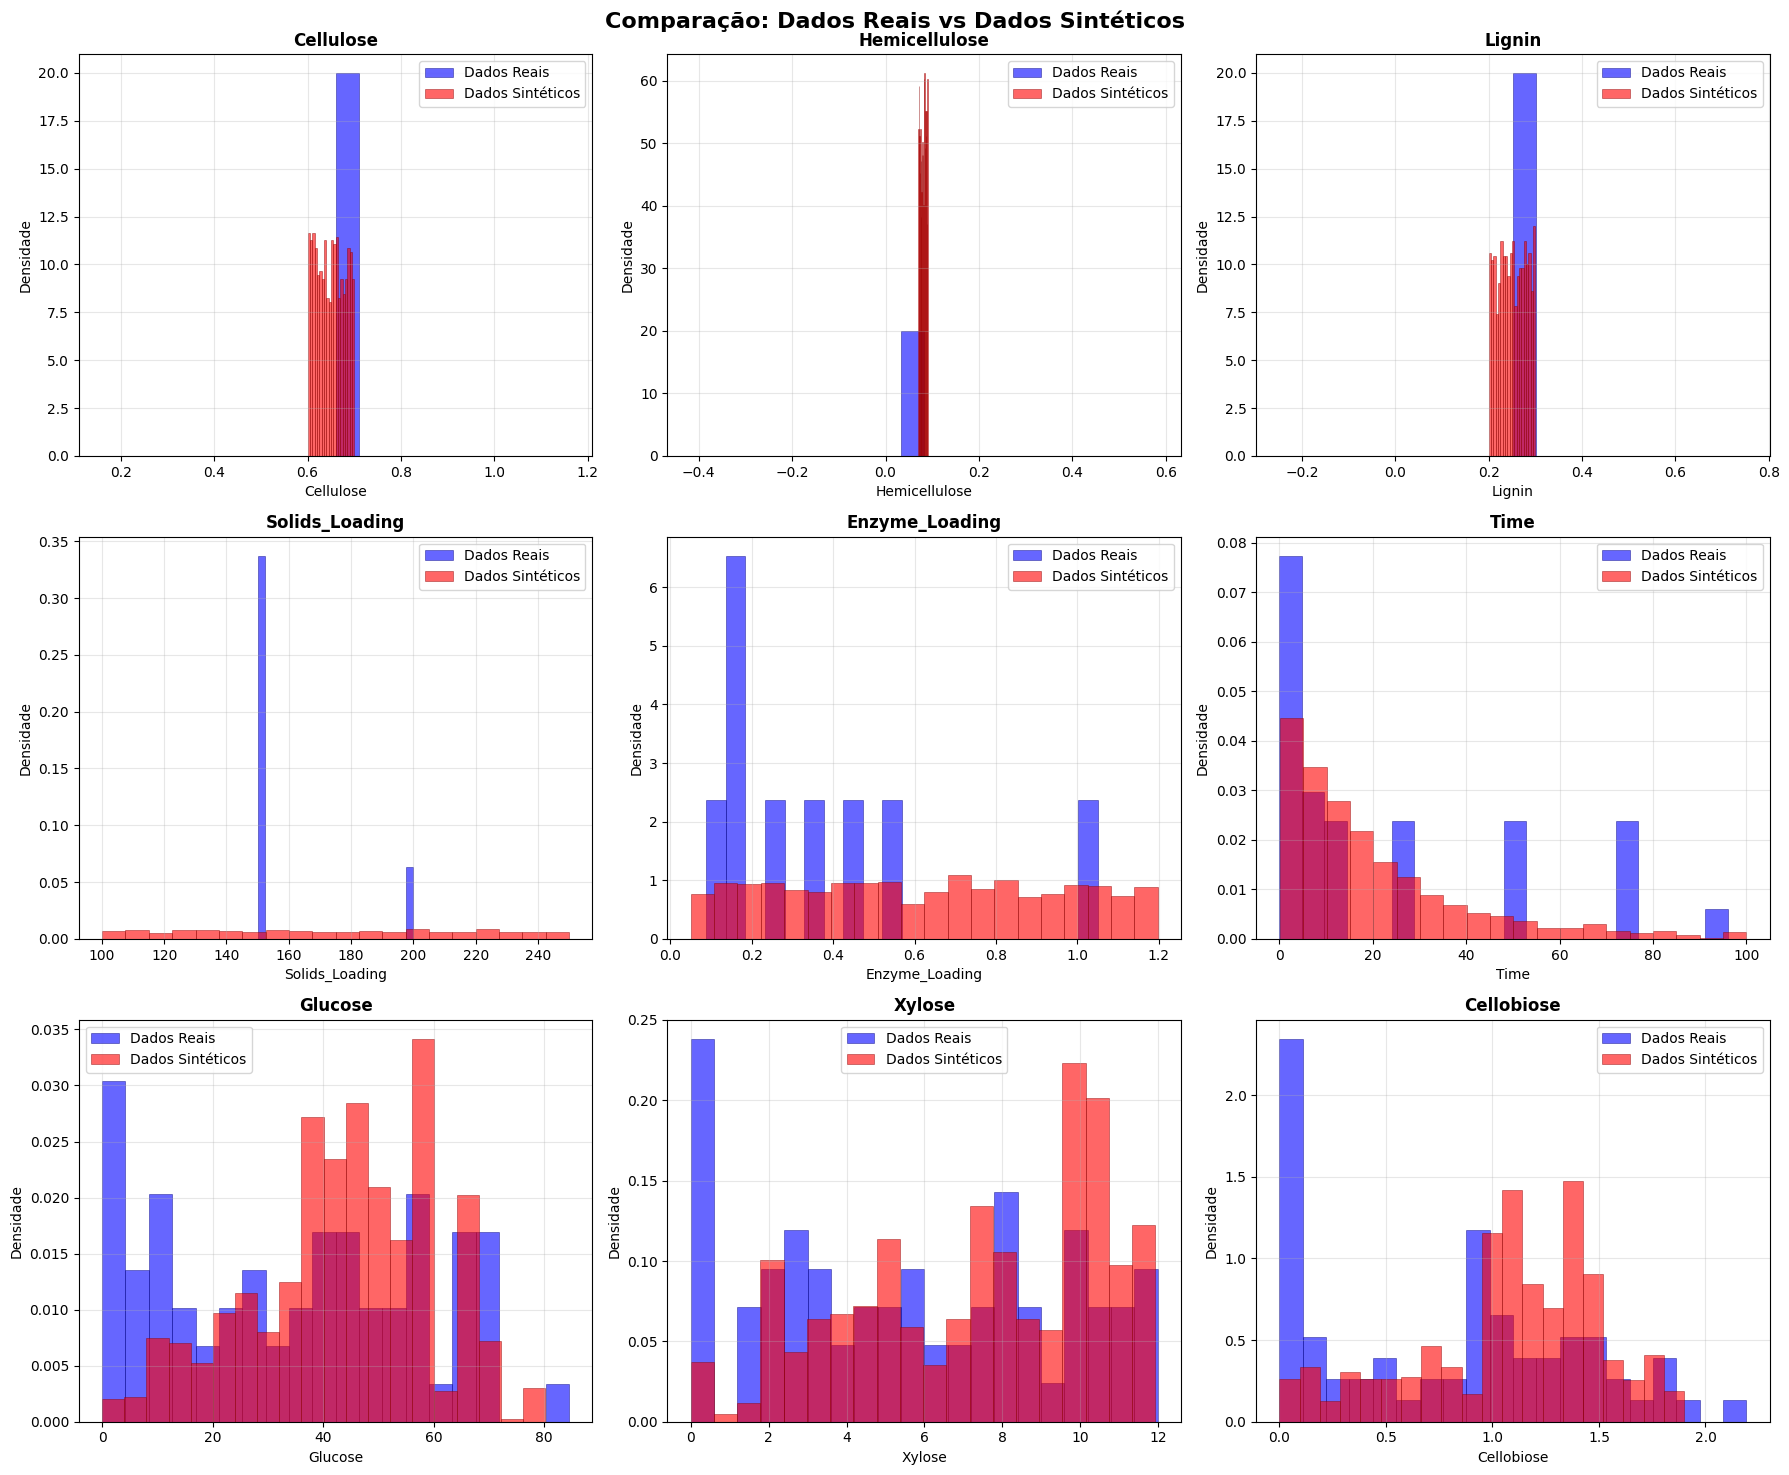

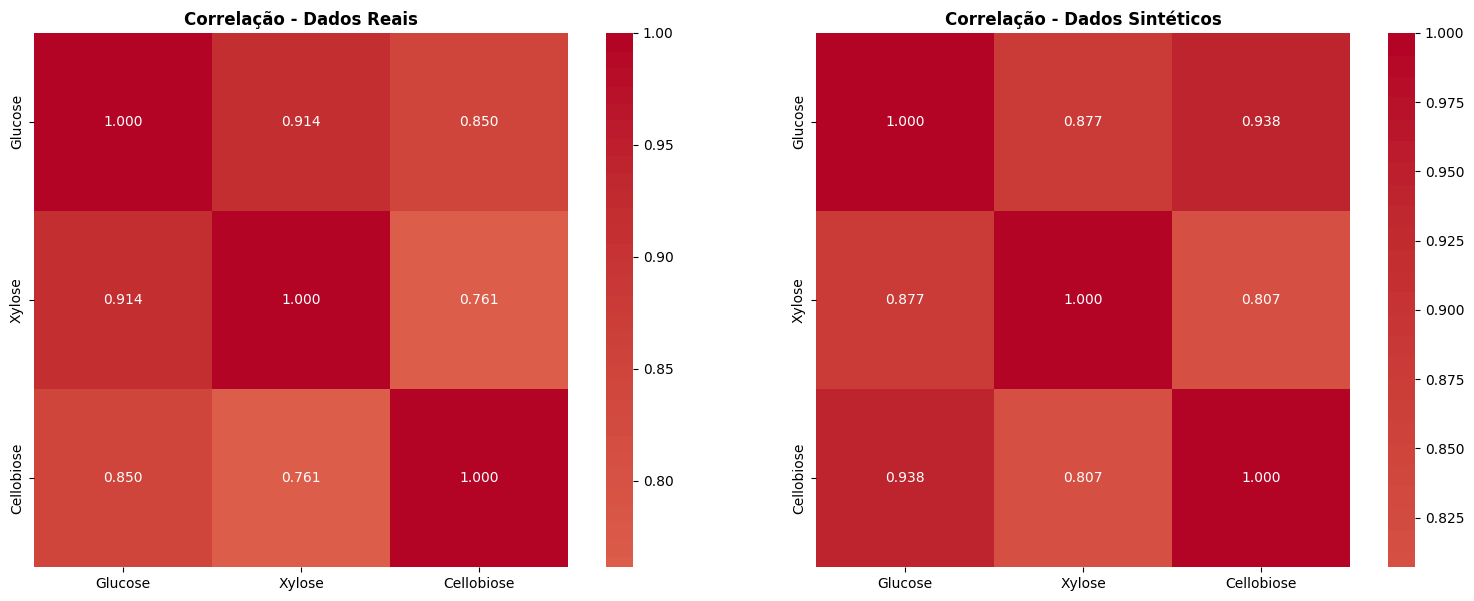

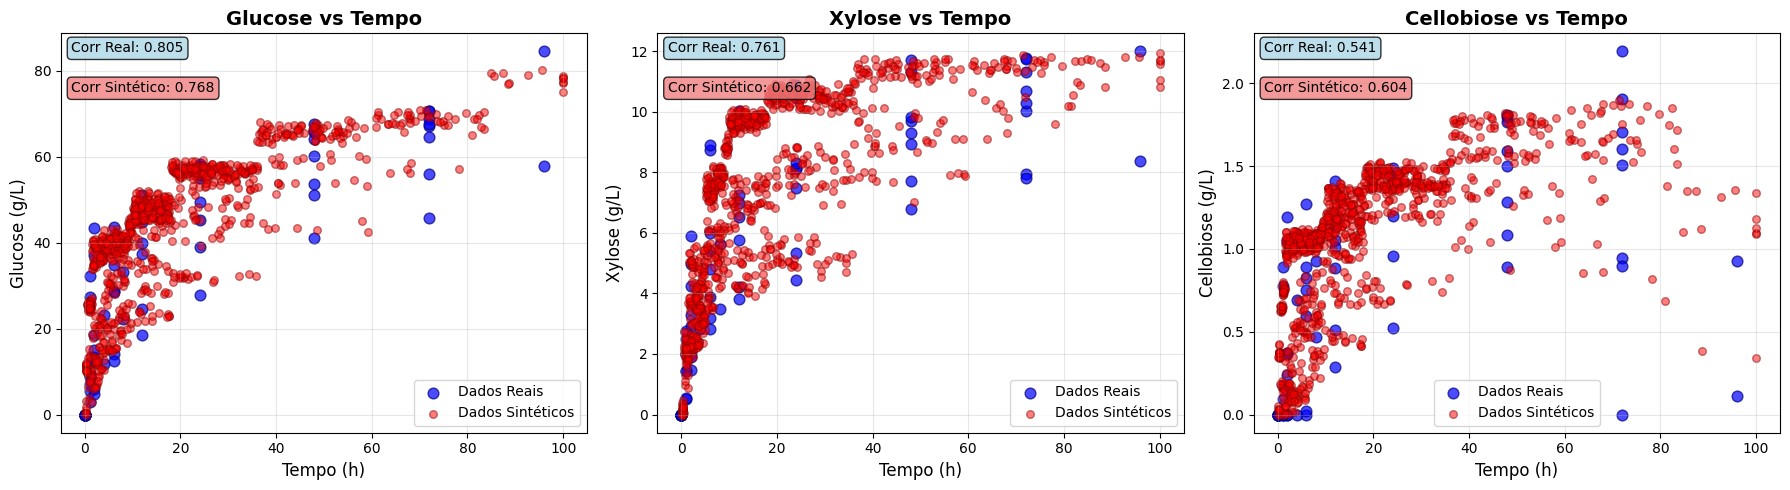

COMPARAÇÃO ESTATÍSTICA: DADOS REAIS vs SINTÉTICOS
            Real_Mean  Synthetic_Mean  Real_Std  Synthetic_Std  Mean_Diff%  \
Glucose        34.449          43.931    23.640         16.173      27.527   
Xylose          5.624           7.417     3.781          3.162      31.887   
Cellobiose      0.768           1.085     0.628          0.433      41.165   

            Std_Diff%  
Glucose        31.587  
Xylose         16.394  
Cellobiose     31.133  

📊 RESUMO:
• Diferença média nas médias: 33.5%
• Diferença média nos desvios: 26.4%
• Amostras reais: 70
• Amostras sintéticas: 1000
• Modelo usado: Random Forest (R² = 0.7981)


In [7]:
# Visualização dos Dados Sintéticos
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")

# Configuração dos gráficos
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Comparação: Dados Reais vs Dados Sintéticos', fontsize=16, fontweight='bold')

# Lista de todas as variáveis para plotar
all_features = input_features + output_targets

# Criar gráficos de distribuição para cada variável
for i, feature in enumerate(all_features):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    # Histograma dos dados reais
    ax.hist(data[feature], bins=20, alpha=0.6, label='Dados Reais', 
            color='blue', density=True, edgecolor='navy', linewidth=0.5)
    
    # Histograma dos dados sintéticos
    ax.hist(synthetic_data[feature], bins=20, alpha=0.6, label='Dados Sintéticos', 
            color='red', density=True, edgecolor='darkred', linewidth=0.5)
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidade')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de correlação entre variáveis de saída
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlação dados reais
corr_real = data[output_targets].corr()
sns.heatmap(corr_real, annot=True, cmap='coolwarm', center=0, 
            ax=axes[0], fmt='.3f', square=True)
axes[0].set_title('Correlação - Dados Reais', fontweight='bold')

# Correlação dados sintéticos
corr_synthetic = synthetic_data[output_targets].corr()
sns.heatmap(corr_synthetic, annot=True, cmap='coolwarm', center=0, 
            ax=axes[1], fmt='.3f', square=True)
axes[1].set_title('Correlação - Dados Sintéticos', fontweight='bold')

plt.tight_layout()
plt.show()

# Scatter plots das variáveis de saída vs Tempo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(output_targets):
    # Dados reais
    axes[i].scatter(data['Time'], data[target], alpha=0.7, 
                   s=60, label='Dados Reais', color='blue', edgecolors='navy')
    
    # Dados sintéticos
    axes[i].scatter(synthetic_data['Time'], synthetic_data[target], alpha=0.5, 
                   s=30, label='Dados Sintéticos', color='red', edgecolors='darkred')
    
    axes[i].set_xlabel('Tempo (h)', fontsize=12)
    axes[i].set_ylabel(f'{target} (g/L)', fontsize=12)
    axes[i].set_title(f'{target} vs Tempo', fontsize=14, fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Calcular correlações
    corr_real = data['Time'].corr(data[target])
    corr_synthetic = synthetic_data['Time'].corr(synthetic_data[target])
    
    # Adicionar texto com correlações
    axes[i].text(0.02, 0.98, f'Corr Real: {corr_real:.3f}', 
                transform=axes[i].transAxes, fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
                verticalalignment='top')
    axes[i].text(0.02, 0.88, f'Corr Sintético: {corr_synthetic:.3f}', 
                transform=axes[i].transAxes, fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8),
                verticalalignment='top')

plt.tight_layout()
plt.show()

# Comparação estatística resumida
print("=" * 60)
print("COMPARAÇÃO ESTATÍSTICA: DADOS REAIS vs SINTÉTICOS")
print("=" * 60)

comparison_stats = pd.DataFrame({
    'Real_Mean': data[output_targets].mean(),
    'Synthetic_Mean': synthetic_data[output_targets].mean(),
    'Real_Std': data[output_targets].std(),
    'Synthetic_Std': synthetic_data[output_targets].std(),
})

comparison_stats['Mean_Diff%'] = abs((comparison_stats['Real_Mean'] - comparison_stats['Synthetic_Mean']) / comparison_stats['Real_Mean'] * 100)
comparison_stats['Std_Diff%'] = abs((comparison_stats['Real_Std'] - comparison_stats['Synthetic_Std']) / comparison_stats['Real_Std'] * 100)

print(comparison_stats.round(3))

print(f"\n📊 RESUMO:")
print(f"• Diferença média nas médias: {comparison_stats['Mean_Diff%'].mean():.1f}%")
print(f"• Diferença média nos desvios: {comparison_stats['Std_Diff%'].mean():.1f}%")
print(f"• Amostras reais: {len(data)}")
print(f"• Amostras sintéticas: {len(synthetic_data)}")
print(f"• Modelo usado: {best_model_name} (R² = {best_score:.4f})")

In [8]:
# Verificação dos Dados Carregados
print("=" * 60)
print("VERIFICAÇÃO DOS DADOS EXPERIMENTAIS CARREGADOS")
print("=" * 60)

print(f"Arquivo carregado: {csv_path}")
print(f"Shape dos dados: {data.shape}")
print(f"Colunas: {list(data.columns)}")

print("\n--- PRIMEIRAS 5 LINHAS DOS DADOS REAIS ---")
print(data.head())

print("\n--- ESTATÍSTICAS DOS DADOS REAIS ---")
print(data[input_features + output_targets].describe())

print("\n--- VERIFICAÇÃO: Valores únicos por variável de entrada ---")
for feature in input_features:
    unique_vals = data[feature].nunique()
    print(f"{feature}: {unique_vals} valores únicos - Range: [{data[feature].min():.3f}, {data[feature].max():.3f}]")

print("\n--- VERIFICAÇÃO: Range das variáveis de saída ---")
for target in output_targets:
    print(f"{target}: [{data[target].min():.3f}, {data[target].max():.3f}] g/L")

# Verificar se os dados estão corretos comparando com o arquivo original
print(f"\n--- COMPARAÇÃO COM ARQUIVO EXPERIMENTAL DATA ---")
print(f"Total de amostras experimentais: {len(data)}")
print(f"Condições experimentais identificadas:")
print(f"• Enzyme_Loading: {sorted(data['Enzyme_Loading'].unique())}")
print(f"• Solids_Loading: {sorted(data['Solids_Loading'].unique())}")
print(f"• Tempos experimentais: {sorted(data['Time'].unique())}")

# Verificar se há valores de composição constante (como esperado nos dados experimentais)
print(f"\n--- COMPOSIÇÃO DA BIOMASSA ---")
print(f"• Celulose: {data['Cellulose'].unique()}")
print(f"• Hemicelulose: {data['Hemicellulose'].unique()}")  
print(f"• Lignina: {data['Lignin'].unique()}")

VERIFICAÇÃO DOS DADOS EXPERIMENTAIS CARREGADOS
Arquivo carregado: c:\Users\audec\OneDrive\Ethanol-AI\BEPE FAPESP\Enzymatic Hydrolysis\Data Generation\Experimental Data.csv
Shape dos dados: (70, 9)
Colunas: ['Cellulose', 'Hemicellulose', 'Lignin', 'Solids_Loading', 'Enzyme_Loading', 'Time', 'Glucose', 'Xylose', 'Cellobiose']

--- PRIMEIRAS 5 LINHAS DOS DADOS REAIS ---
   Cellulose  Hemicellulose  Lignin  Solids_Loading  Enzyme_Loading  Time  \
0       0.66          0.083   0.252           150.0           0.175   0.0   
1       0.66          0.083   0.252           150.0           0.175   1.0   
2       0.66          0.083   0.252           150.0           0.175   2.0   
3       0.66          0.083   0.252           150.0           0.175   4.0   
4       0.66          0.083   0.252           150.0           0.175   6.0   

   Glucose  Xylose  Cellobiose  
0    0.000   0.000       0.000  
1    8.772   1.435       0.175  
2   13.363   2.007       0.367  
3   23.095   2.829       0.691  
4 